# 03 — Ripple Microstructure Features

**Strategy reference:** §9.5 (Mathematical formalisation).

Ripple is the *only* layer that triggers trades.  Before the wall
detector / state machine / trade lifecycle, Ripple runs a feature
engine that computes the canonical L2 microstructure observables:

| symbol | name |
|---|---|
| $I_t$ | order-book imbalance |
| $P_\mu$ | microprice |
| $\text{OFI}_t$ | order-flow imbalance |
| $\text{CVD}_t$ | cumulative volume delta |
| $\lambda_t$ | price impact per unit aggressive volume |
| $\text{VPIN}_t$ | volume-bucket toxicity |
| LSI | composite microstructure stress |

We compute each from the tick HDF5 in pure Python — the C++ Ripple
engine implements the exact same formulas in its production hot
path.  Reproducing them here keeps the notebook self-contained
and shows the math explicitly.

In [1]:
# ── Data-source configuration ─────────────────────────────────────────
# OHLCV (Parquet) — S3 or local, controlled by DATA_STORE env var:
#   Local (default):  reads <project_root>/data/ohlcv/...
#   S3:               uncomment the two lines below
# import os
# os.environ["DATA_STORE"] = "s3"
# os.environ["S3_BUCKET"]  = "trading-data-centheos"
#
# Tick data (HDF5) — always stored locally; pull from S3 on demand:
#   load_ticks(...)              → use local cache (fast, no network)
#   load_ticks(..., refresh=True) → sync from S3 then read (ETag-gated)
#   Requires: AWS_PROFILE=trading (or AWS_ACCESS_KEY_ID / AWS_SECRET_ACCESS_KEY)
import os
os.environ["AWS_PROFILE"] = "trading"
os.environ["S3_BUCKET"]   = "trading-data-centheos"
# ─────────────────────────────────────────────────────────────────────

import sys, importlib
from pathlib import Path

_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    if (_cand / "schemas.py").exists():
        _root = _cand; break
else:
    raise RuntimeError("Could not locate project root (no schemas.py found)")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import notebooks.utils as _utils_mod
importlib.reload(_utils_mod)   # always pick up on-disk changes without restarting the kernel

from notebooks.utils import (
    load_ohlcv, list_ohlcv, load_ticks, latest_book,
    plot_ohlcv, plot_equity_curve, configure_pandas, env_summary,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

configure_pandas()
%matplotlib inline

## 1. Load tick data

In [2]:
symbol = 'BTCUSDT'

# refresh=False (default) — use local cache, no network access (fast).
# refresh=True            — ETag-check S3 and download only if the collector
#                           has uploaded newer data since the last refresh.
#                           Do this once when you want the latest tick data;
#                           subsequent runs stay fast until you refresh again.
ticks = load_ticks(symbol,
                   max_trades=10_000,
                   max_depth_snapshots=100_000,
                   max_depth_updates=100_000,
                   refresh=False)   # ← set True to pull latest from S3
trades   = ticks['trades']
snaps    = ticks['depth_snapshots']
updates  = ticks['depth_updates']
for k, df in ticks.items():
    print(f'{k:18s} rows={len(df):,}')

binance_ticks.h5:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

  Saved → /Users/clintsellen/Documents/Trading/app/backtest/data/cache/binance_ticks.h5  (3.53 GB)


OSError: Unable to open file (bad object header version number)

In [10]:
# ── Data ceiling summary ──────────────────────────────────────────────
# This shows the maximum rows available in the local HDF5 regardless of
# what cap you pass to load_ticks.  If a dataset shows fewer rows than
# your cap it means the file simply doesn't have more data.  The fix
# is to collect more ticks (collect_ticks.py) or pull from S3.
rows = {k: len(v) for k, v in ticks.items()}
for k, df in ticks.items():
    if df.empty:
        print(f"  {k:22s}  rows={rows[k]:>6,}  ← EMPTY")
    else:
        ts = pd.to_datetime(df['timestamp'], unit='ms')
        print(f"  {k:22s}  rows={rows[k]:>6,}  {ts.min().strftime('%Y-%m-%d %H:%M')} → {ts.max().strftime('%Y-%m-%d %H:%M')}")

  trades                  rows= 1,951  2026-03-07 01:52 → 2026-05-15 04:59
  depth_snapshots         rows= 3,904  2026-03-07 01:52 → 2026-05-20 12:25
  depth_updates           rows=75,019  2026-03-07 01:52 → 2026-05-20 12:27


## 2. Reconstruct top-of-book over time
We aggregate each snapshot's best bid / best ask into a time
series.  Each row is one snapshot timestamp.

In [11]:
def tob_per_snapshot(snap_df: pd.DataFrame) -> pd.DataFrame:
    if snap_df.empty:
        return pd.DataFrame(columns=['bid_p','bid_q','ask_p','ask_q'])
    bids = snap_df[snap_df['side'] == 0]
    asks = snap_df[snap_df['side'] == 1]
    best_bid = bids.groupby('timestamp').apply(
        lambda g: g.nlargest(1, 'price').iloc[0], include_groups=False
    )[['price','quantity']].rename(columns={'price':'bid_p','quantity':'bid_q'})
    best_ask = asks.groupby('timestamp').apply(
        lambda g: g.nsmallest(1, 'price').iloc[0], include_groups=False
    )[['price','quantity']].rename(columns={'price':'ask_p','quantity':'ask_q'})
    return best_bid.join(best_ask, how='inner').sort_index()

tob = tob_per_snapshot(snaps)
tob['mid']    = 0.5 * (tob['bid_p'] + tob['ask_p'])
tob['spread'] = tob['ask_p'] - tob['bid_p']
tob.head()

,bid_p,bid_q,ask_p,ask_q,mid,spread
timestamp,,,,,,
1772848328625,"68,289.900000",7.216000,"68,290.000000",0.633000,"68,289.950000",0.100000
1773016264042,"66,249.900000",9.417000,"66,250.000000",0.225000,"66,249.950000",0.100000


## 3. Order-book imbalance (§9.5.1)
$$I_t = \frac{V^b_t - V^a_t}{V^b_t + V^a_t}\in[-1,1]$$

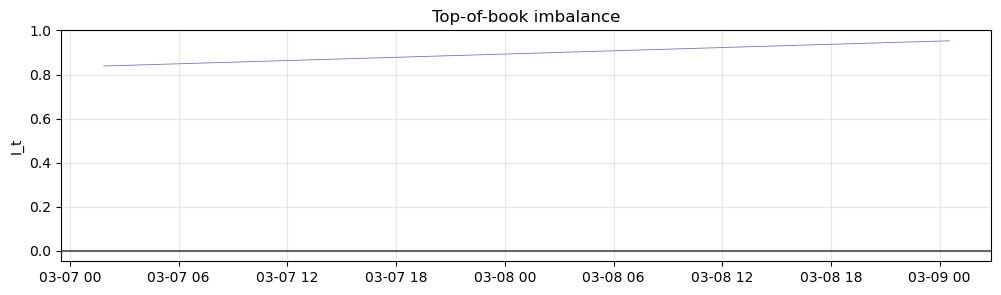

In [12]:
tob['imbalance'] = (tob['bid_q'] - tob['ask_q']) / (tob['bid_q'] + tob['ask_q']).replace(0, np.nan)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(pd.to_datetime(tob.index, unit='ms'), tob['imbalance'], color='#9467bd', linewidth=0.6)
ax.axhline(0, color='#666')
ax.set_title('Top-of-book imbalance'); ax.set_ylabel('I_t'); ax.grid(alpha=0.3)
plt.show()

## 4. Microprice (§9.5.2)
$$P_\mu = P^a \cdot \frac{V^b}{V^b+V^a} + P^b \cdot \frac{V^a}{V^b+V^a}$$

Size-weighted fair value — leans toward the side that has *less*
depth (because that's where price would more easily move).

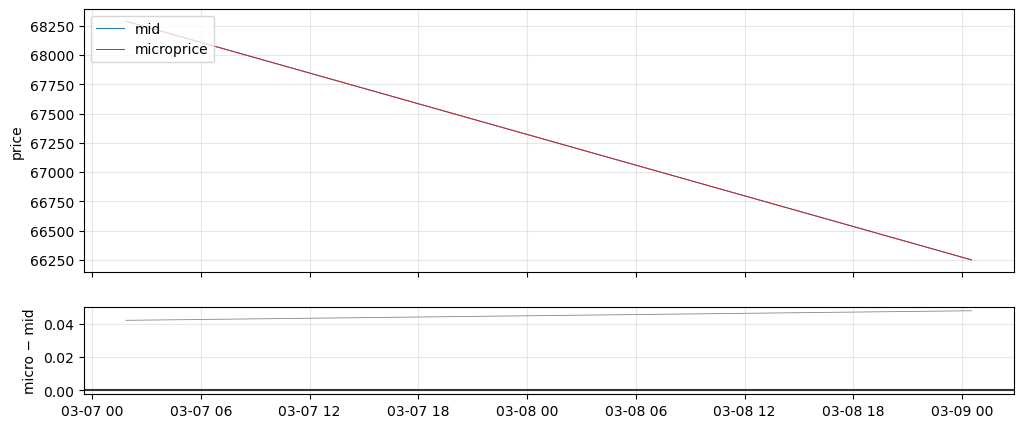

In [7]:
denom = (tob['bid_q'] + tob['ask_q']).replace(0, np.nan)
tob['microprice'] = tob['ask_p'] * (tob['bid_q'] / denom) + tob['bid_p'] * (tob['ask_q'] / denom)
tob['micro_minus_mid'] = tob['microprice'] - tob['mid']

ts_dt = pd.to_datetime(tob.index, unit='ms')
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(ts_dt, tob['mid'],        color='#1f77b4', linewidth=0.7, label='mid')
axes[0].plot(ts_dt, tob['microprice'], color='#d62728', linewidth=0.7, label='microprice')
axes[0].legend(loc='upper left'); axes[0].grid(alpha=0.3); axes[0].set_ylabel('price')
axes[1].plot(ts_dt, tob['micro_minus_mid'], color='#888', linewidth=0.6)
axes[1].axhline(0, color='#333')
axes[1].set_ylabel('micro − mid'); axes[1].grid(alpha=0.3)
plt.show()

## 5. Order-Flow Imbalance (§9.5.3)
$$\text{OFI}_t = \Delta V^b_t - \Delta V^a_t$$

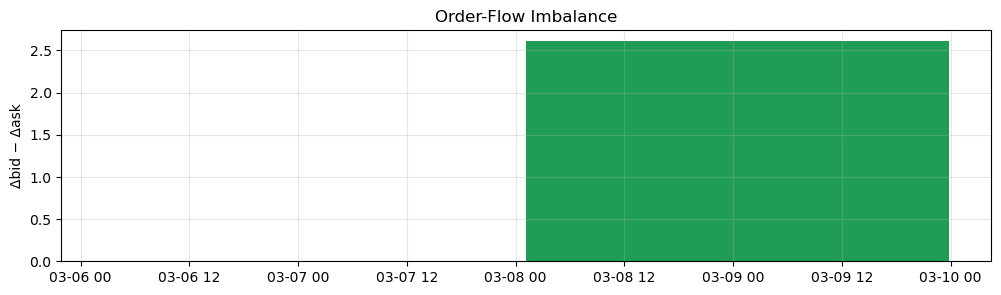

In [7]:
tob['ofi'] = tob['bid_q'].diff() - tob['ask_q'].diff()
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(ts_dt, tob['ofi'].fillna(0), color=np.where(tob['ofi'] >= 0, '#1f9d55', '#cc1f1a'),
       width=(ts_dt[1] - ts_dt[0]).total_seconds() / 86400 if len(ts_dt) > 1 else 0.001)
ax.set_title('Order-Flow Imbalance'); ax.set_ylabel('Δbid − Δask'); ax.grid(alpha=0.3)
plt.show()

## 6. Cumulative Volume Delta (§9.5.4)
$$\text{CVD}_t = \sum_{\tau \le t} (Q^{\text{buy}}_\tau - Q^{\text{sell}}_\tau)$$

The HDF5 trade row carries `is_buyer_maker`.  If the buyer is the
*maker*, then the aggressor is the *seller* → counts as `Q^sell`.

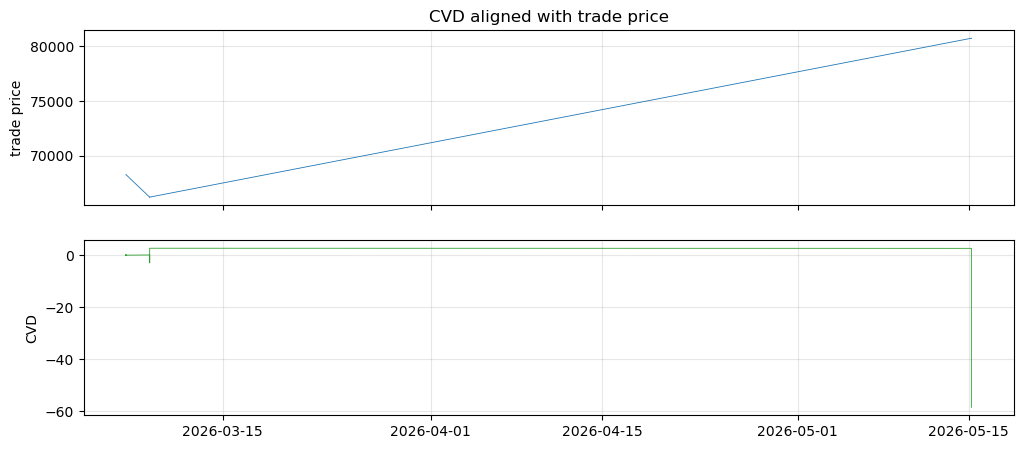

In [8]:
trades['ts']    = pd.to_datetime(trades['timestamp'], unit='ms')
trades['signed'] = np.where(trades['is_buyer_maker'],
                             -trades['quantity'],  # sell aggressor
                              trades['quantity'])  # buy  aggressor
trades['cvd'] = trades['signed'].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(trades['ts'], trades['price'], color='#1f77b4', linewidth=0.6)
axes[0].set_ylabel('trade price'); axes[0].grid(alpha=0.3)
axes[1].plot(trades['ts'], trades['cvd'], color='#2ca02c', linewidth=0.6)
axes[1].set_ylabel('CVD'); axes[1].grid(alpha=0.3)
axes[0].set_title('CVD aligned with trade price')
plt.show()

## 7. Price impact $\lambda_t$ (§9.5.5)
$$\lambda_t = \frac{\Delta P_t}{Q^{\text{aggressor}}_t}$$

Aggregate trades into 1-second buckets, compute the signed
aggressor flow and the close-to-close price change, then divide.

In [9]:
bucket = (trades.set_index('ts')
                  .resample('1s')
                  .agg(signed_qty=('signed','sum'),
                       last_price=('price','last'))
                  .dropna())
bucket['dp'] = bucket['last_price'].diff()
bucket['lambda'] = bucket['dp'] / bucket['signed_qty'].replace(0, np.nan)
bucket[['signed_qty','dp','lambda']].describe()

,signed_qty,dp,lambda
count,28.000000,27.000000,27.000000
mean,-2.091893,459.103704,"-1,607.508390"
std,11.619092,"2,822.646069","8,381.413835"
min,-61.099000,"-2,046.600000","-43,544.680851"
25%,-0.200750,-0.400000,-0.000000
50%,0.009000,0.000000,0.083612
75%,0.055500,0.050000,20.326087
max,5.363000,"14,444.800000",112.000000


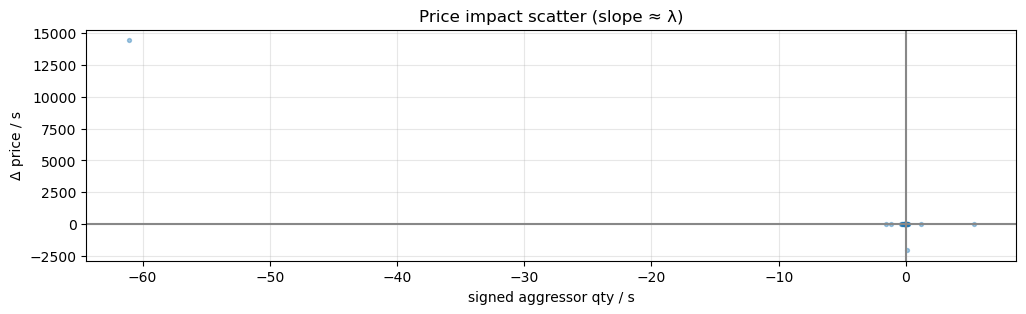

In [10]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(bucket['signed_qty'], bucket['dp'], s=8, alpha=0.4, color='#1f77b4')
ax.axhline(0, color='#888'); ax.axvline(0, color='#888')
ax.set_xlabel('signed aggressor qty / s')
ax.set_ylabel('Δ price / s')
ax.set_title('Price impact scatter (slope ≈ λ)')
ax.grid(alpha=0.3); plt.show()

## 8. VPIN (§9.5.6) — volume-bucket toxicity
Use **volume-time** bars of fixed size, not clock time.

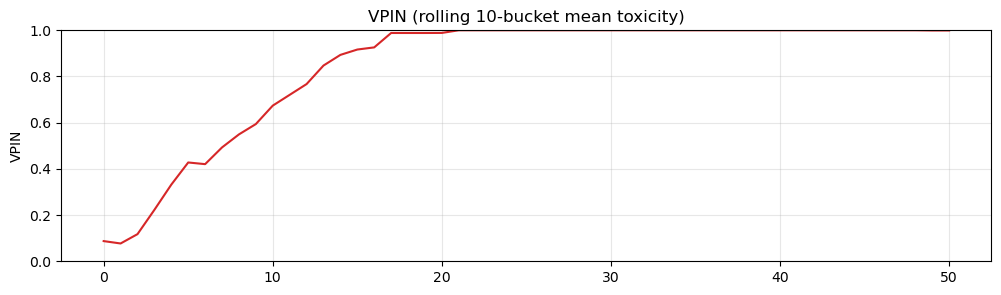

,vpin
count,45.000000
mean,0.828817
std,0.289676
min,0.077049
25%,0.767168
50%,1.000000
75%,1.000000
max,1.000000


In [11]:
bar_volume = float(trades['quantity'].sum() / 50)   # ~50 buckets total
cum = trades['quantity'].cumsum()
trades['bucket'] = (cum // bar_volume).astype(int)
vpin_bars = trades.groupby('bucket').agg(
    buy =('quantity', lambda s: s[~trades.loc[s.index,'is_buyer_maker']].sum()),
    sell=('quantity', lambda s: s[ trades.loc[s.index,'is_buyer_maker']].sum()),
)
vpin_bars['toxicity'] = (vpin_bars['buy'] - vpin_bars['sell']).abs() / (vpin_bars['buy'] + vpin_bars['sell'])
vpin_bars['vpin'] = vpin_bars['toxicity'].rolling(10, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(vpin_bars.index, vpin_bars['vpin'], color='#d62728')
ax.set_title('VPIN (rolling 10-bucket mean toxicity)')
ax.set_ylabel('VPIN'); ax.set_ylim(0, 1); ax.grid(alpha=0.3)
plt.show()
vpin_bars[['vpin']].describe()

## 9. Ripple LSI (§9.5.8)
Composite z-scored stress: spread (positive when wide), depth
(inverted), impact, cancellation.  We have spread and depth from
the snapshots and a depth-cancellation proxy from the difference.

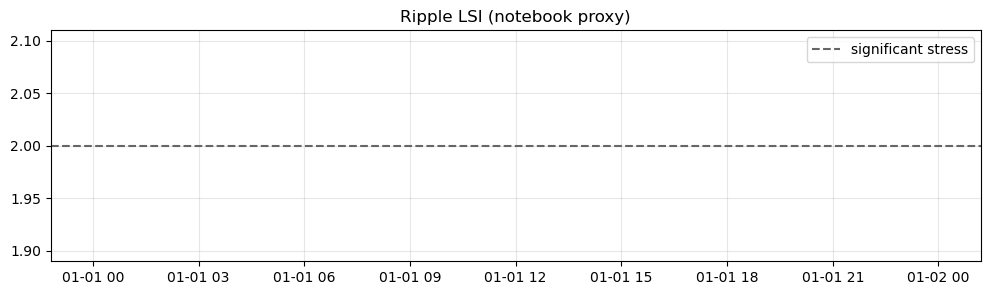

In [12]:
tob['top_depth'] = tob['bid_q'] + tob['ask_q']
zspread = (tob['spread'] - tob['spread'].rolling(200).mean()) / tob['spread'].rolling(200).std()
zdepth  = (tob['top_depth'] - tob['top_depth'].rolling(200).mean()) / tob['top_depth'].rolling(200).std()
tob['lsi_ripple'] = 0.5 * zspread + 0.5 * (1 - zdepth)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(ts_dt, tob['lsi_ripple'], color='#d62728', linewidth=0.6)
ax.axhline(2.0, ls='--', color='#666', label='significant stress')
ax.set_title('Ripple LSI (notebook proxy)'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Takeaways

* Imbalance, microprice, OFI and CVD are *direct* observables of
  the resting-vs-aggressive interaction that drives price.
* $\lambda$ is the structural ingredient in the LSI: a thin book
  moves more per unit of aggression.
* VPIN's strength is that it normalises away clock time.  Bursty
  toxic flow flags up regardless of bar size.